In [1]:
import numpy as np

# -----------------------
# Physical constants (cgs)
# -----------------------
AU   = 1.495978707e13
RSUN = 6.957e10
MSUN = 1.98847e33
SIGMA_SB = 5.670374419e-5   # erg cm^-2 s^-1 K^-4
PI = np.pi

# -----------------------
# Dullemond+2002 fiducial stellar + surface density parameters
# (used in their example vertical-structure plots)
# -----------------------
Teff = 3000.0               # K
Rstar = 2.0 * RSUN          # cm
Mstar = 0.5 * MSUN          # g
Sigma_1AU = 1e3             # g/cm^2 at 1 AU (their example)
pSigma = 1.0                # Sigma ~ R^-1 per caption

# -----------------------
# Annulus location and prescribed vertical density
# -----------------------
R = 1 * AU                # choose 1 AU annulus (their example plot)
Sigma = Sigma_1AU * (R/AU)**(-pSigma)

# Prescribed Gaussian scale height (since you said: no density iteration)
# Choose something plausible; you can tune. (Hydrostatic iteration omitted)
H = 0.05 * R                # cm  (set by hand)

# Vertical grid
nz = 70
zmax = 6.0 * H
z = np.linspace(0.0, zmax, nz)   # only upper half (midplane symmetry)
dz = z[1] - z[0]

rho0 = Sigma / (np.sqrt(2*PI) * H)
rho = rho0 * np.exp(-0.5*(z/H)**2)

# -----------------------
# MEMO boundary parameter
# -----------------------
psi = 1.0/np.sqrt(3.0)   # H/J at surface for Eddington/Marshak BC

# -----------------------
# Opacity parametrization (power-law placeholder)
# Later: replace these with tabulated opacities.
# -----------------------
Tref = 100.0  # K
kappaP0 = 1.0 # cm^2/g at Tref
kappaR0 = 1.0 # cm^2/g at Tref
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    # Planck mean (absorption/emission coupling)
    T = np.maximum(T, 1.0)
    return kappaP0 * (T/Tref)**betaP

def kappaR(T):
    # Rosseland mean (transport)
    T = np.maximum(T, 1.0)
    return kappaR0 * (T/Tref)**betaR

# Stellar/irradiation "opacity" (absorption of stellar photons)
# In Dullemond+2002, full frequency-dependent stellar RT is used in the "full" method.
# For MEMO toy, pick a constant or a Planck-mean at Teff.
kappa_star = kappaP(Teff)   # crude stand-in; you can set a constant instead

# Grazing incidence parameter for the stellar beam
# Used only in exp(-tau/mu0). Typical grazing angles are small; tune as needed.
mu0 = 0.05

# Stellar flux at radius R (normal incidence)
F_star = (Rstar/R)**2 * SIGMA_SB * Teff**4  # erg/cm^2/s

def stellar_heating_q(rho, z, kappa_star, F_star, mu0):
    """
    Simple 1D attenuated grazing beam from +z:
        tau(z) = ∫_z^∞ rho kappa_star dz'
        q(z) = rho kappa_star F_star * exp(-tau/mu0)
    (Units: erg cm^-3 s^-1)

    This is a simplified 'direct irradiation' heating profile.
    """
    # optical depth from top downward (compute on upper-half grid)
    # tau_top[i] = ∫_{z[i]}^{zmax} rho*kappa dz
    integrand = rho * kappa_star
    tau_top = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(len(z)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(z[i+1]-z[i])

    q = rho * kappa_star * F_star * np.exp(-tau_top/np.maximum(mu0, 1e-6))
    return q, tau_top

# -----------------------
# Tridiagonal solver (Thomas algorithm)
# -----------------------
def solve_tridiag(a, b, c, d):
    """
    Solve tridiagonal system with diagonals:
      a: sub-diagonal (n-1)
      b: main diagonal (n)
      c: super-diagonal (n-1)
      d: rhs (n)
    """
    n = len(b)
    cp = np.zeros(n-1)
    dp = np.zeros(n)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n-1):
        denom = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i-1]*dp[i-1]) / denom

    denom = b[n-1] - a[n-2]*cp[n-2]
    dp[n-1] = (d[n-1] - a[n-2]*dp[n-2]) / denom

    x = np.zeros(n)
    x[n-1] = dp[n-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i]*x[i+1]
    return x

# -----------------------
# Assemble and solve MEMO ODE for J:
#   d/dz [ D dJ/dz ] = rho kappaP (J - B)
# where D = 1/(3 rho kappaR),  B = sigma/pi * T^4
#
# And temperature from local radiative equilibrium with external heating q(z):
#   4*pi*rho*kappaP(T)*(B(T) - J) = q(z)
#
# Iterate because kappaP,kappaR depend on T.
# -----------------------
def solve_vertical_MEMO(max_iter=100, tol=1e-4, relax=0.3,
                        Tmin=3.0, Tmax=2000.0, verbose=True):

    # initial guess temperature profile (choose something reasonable)
    T = 100. * (R/AU)**(-0.5) * np.ones_like(z)

    for it in range(max_iter):
        # Heating profile from direct irradiation
        q, tau_top = stellar_heating_q(rho, z, kappa_star, F_star, mu0)

        kapP = kappaP(T)
        kapR = kappaR(T)

        # Diffusion coefficient at cell centers
        D = 1.0 / (3.0 * rho * kapR + 1e-200)

        # Build tridiagonal for J
        # Discretize: (D_{i+1/2}(J_{i+1}-J_i) - D_{i-1/2}(J_i-J_{i-1}))/dz^2 = rho_i kapP_i (J_i - B_i)
        # => -A_i J_{i-1} + (A_i+C_i + rho kapP) J_i - C_i J_{i+1} = rho kapP B
        B = (SIGMA_SB/PI) * T**4

        # Interface D's
        Dp = 0.5*(D[1:] + D[:-1])  # at i+1/2, length nz-1

        a = np.zeros(nz-1)  # sub
        b = np.zeros(nz)    # main
        c = np.zeros(nz-1)  # super
        rhs = np.zeros(nz)

        # i = 0: midplane symmetry dJ/dz = 0 => J_1 - J_0 = 0
        # Implement as: J0 - J1 = 0  (or J0 = J1)
        b[0] = 1.0
        c[0] = -1.0
        rhs[0] = rho[0]*kapP[0]*B[0]

        # interior points
        for i in range(1, nz-1):
            A = Dp[i-1] / dz**2
            C = Dp[i]   / dz**2
            a[i-1] = -A
            b[i]   = (A + C) + rho[i]*kapP[i]
            c[i]   = -C
            rhs[i] = rho[i]*kapP[i]*B[i]

        # i = nz-1: surface Robin BC:
        #   -D dJ/dz = psi * J    at z=zmax
        # with backward diff: dJ/dz ~ (J_N - J_{N-1})/dz
        # => -D_N * (J_N - J_{N-1})/dz = psi J_N
        # => (D_N/dz + psi) J_N - (D_N/dz) J_{N-1} = 0
        DN = D[-1]
        a[-1] = -(DN/dz)
        b[-1] = (DN/dz + psi)
        rhs[-1] = 0.0

        # Solve for J
        J = solve_tridiag(a, b, c, rhs)


        #return z, rho, T, J

        # Update T from local radiative equilibrium:
        #   4*pi*rho*kappaP(T)*(B(T)-J) = q
        # where B(T)=sigma/pi*T^4
        Tnew = np.zeros_like(T)

        for i in range(nz):
            # Define function f(T) = 4*pi*rho*kappaP(T)*(sigma/pi*T^4 - J) - q
            # Solve for root in [Tmin, Tmax] by bisection
            ri = rho[i]
            Ji = J[i]
            qi = q[i]

            lo, hi = Tmin, Tmax

            def f(Tx):
                kap = kappaP(Tx)
                Bx = (SIGMA_SB/PI) * Tx**4
                return 4.0*PI*ri*kap*(Bx - Ji) - qi

            flo = f(lo)
            fhi = f(hi)

            # If bracket fails, fallback to clipping:
            if flo*fhi > 0:
                # If both positive, lower T; if both negative, raise T
                # Use a heuristic single-step:
                if abs(flo) < abs(fhi):
                    Tx = lo
                else:
                    Tx = hi
                Tnew[i] = Tx
                
            else:
                for _ in range(80):
                    mid = 0.5*(lo+hi)
                    fmid = f(mid)
                    if flo*fmid <= 0:
                        hi = mid
                        fhi = fmid
                    else:
                        lo = mid
                        flo = fmid
                Tnew[i] = 0.5*(lo+hi)

        
        # Under-relax for stability
        Told = T.copy()
        T = (1.0-relax)*T + relax*Tnew

        # Convergence check
        rel = np.max(np.abs((T - Told)/np.maximum(Told, 1.0)))
        if verbose and (it % 10 == 0 or rel < tol):
            print(f"iter={it:4d}  max_rel_dT={rel:.3e}  Tmid={T[0]:.2f} K  Tsfc={T[-1]:.2f} K")

        if rel < tol:
            break

    # Mirror to full z (optional) for plotting
    #z_full = np.concatenate((-z[:0:-1], z))
    #T_full = np.concatenate((T[:0:-1], T))
    #rho_full = np.concatenate((rho[:0:-1], rho))
    #J_full = np.concatenate((J[:0:-1], J))
    return z, rho, T, J
    return z_full, rho_full, T_full, J_full

if __name__ == "__main__":
    zf, rhof, Tf, Jf = solve_vertical_MEMO(verbose=True)
    print("\nDone.")
    print(f"Midplane T = {Tf[len(Tf)//2]:.2f} K")


iter=   0  max_rel_dT=7.509e-01  Tmid=100.00 K  Tsfc=175.09 K
iter=  10  max_rel_dT=1.494e-02  Tmid=100.00 K  Tsfc=345.63 K
iter=  20  max_rel_dT=3.779e-03  Tmid=100.00 K  Tsfc=350.61 K
iter=  30  max_rel_dT=2.003e-03  Tmid=100.00 K  Tsfc=350.79 K
iter=  40  max_rel_dT=1.349e-03  Tmid=100.00 K  Tsfc=350.82 K
iter=  50  max_rel_dT=1.022e-03  Tmid=100.00 K  Tsfc=350.83 K
iter=  60  max_rel_dT=8.173e-04  Tmid=100.00 K  Tsfc=350.84 K
iter=  70  max_rel_dT=6.823e-04  Tmid=100.00 K  Tsfc=350.85 K
iter=  80  max_rel_dT=5.808e-04  Tmid=100.00 K  Tsfc=350.85 K
iter=  90  max_rel_dT=5.129e-04  Tmid=100.00 K  Tsfc=350.86 K

Done.
Midplane T = 111.73 K


In [ ]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, )

NameError: name 'q' is not defined

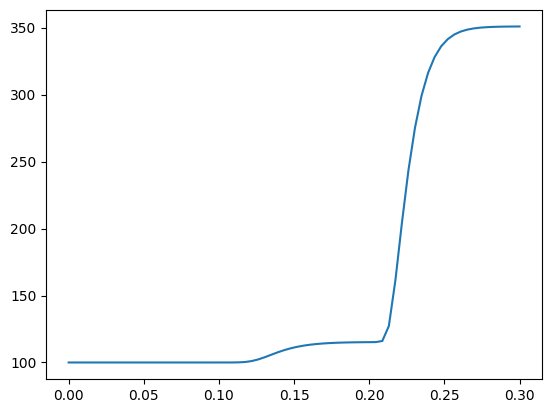

In [93]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, Tf)

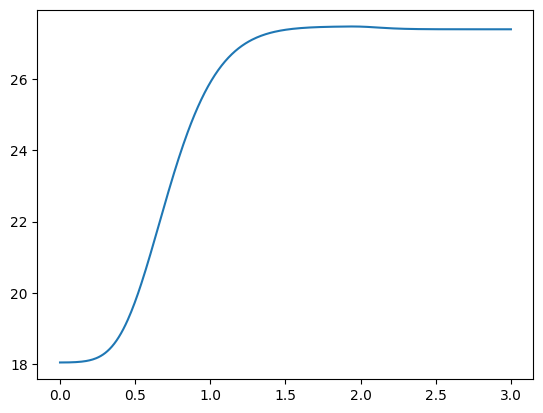

In [89]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, Jf)

In [24]:
q, tau_top, = stellar_heating_q(rho, z, kappa_star, F_star, mu0)

(1e-27, 1e-07)

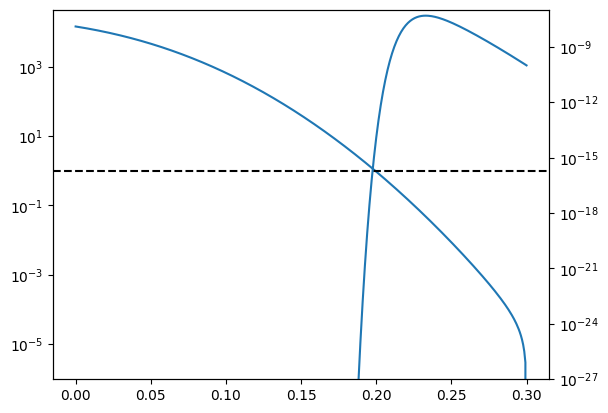

In [50]:
plt.plot(z/AU, tau_top)
plt.axhline(y=1.0, color='k', linestyle='--', label='tau=1')
plt.semilogy()
plt.twinx()
plt.plot(z/AU, q)
plt.semilogy()
plt.ylim(1e-27, 1e-7)

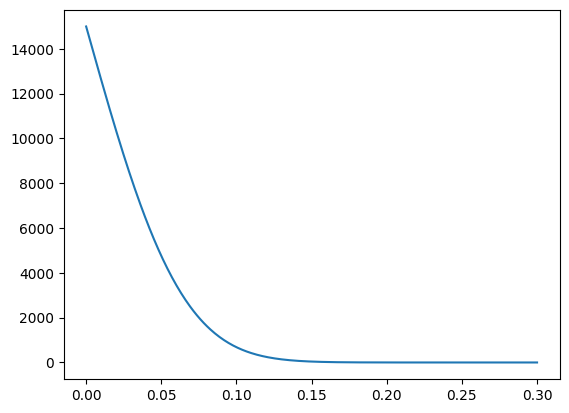

In [94]:
import numpy as np

AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi

# ---- parameters (same as before) ----
Teff = 3000.0
Rstar = 2.0 * RSUN
Sigma_1AU = 1e3
pSigma = 1.0

R = 1.0 * AU
Sigma = Sigma_1AU * (R/AU)**(-pSigma)

H = 0.05 * R

nz = 600
zmax = 10.0 * H  # IMPORTANT at small R
psi = 1.0/np.sqrt(3.0)

# opacities (placeholder)
Tref = 100.0
kappaP0 = 1.0
kappaR0 = 1.0
betaP = 1.0
betaR = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0*(T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0*(T/Tref)**betaR

kappa_star = kappaP(Teff)
mu0 = 0.05
alpha_graz = 0.05
F_star_norm = (Rstar/R)**2 * SIGMA_SB * Teff**4
F0 = alpha_graz * F_star_norm

# ---- stretched grid: cluster points near surface ----
p_stretch = 3.0
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch
dz = np.diff(z)

# prescribed Gaussian rho on this grid
rho0 = Sigma / (np.sqrt(2*PI) * H)
rho = rho0 * np.exp(-0.5*(z/H)**2)

def solve_tridiag(a, b, c, d):
    n = len(b)
    cp = np.zeros(n-1)
    dp = np.zeros(n)
    cp[0] = c[0]/b[0]
    dp[0] = d[0]/b[0]
    for i in range(1, n-1):
        denom = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i]/denom
        dp[i] = (d[i] - a[i-1]*dp[i-1])/denom
    denom = b[n-1] - a[n-2]*cp[n-2]
    dp[n-1] = (d[n-1] - a[n-2]*dp[n-2])/denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i]*x[i+1]
    return x

def stellar_heating_q_conservative(rho, z, kappa_star, F0, mu0):
    """
    Conservative heating: q_i = -(F_{i+1/2}-F_{i-1/2})/Δz_i
    """
    n = len(z)
    # interfaces: 0..n-1 correspond to z_i. Build mid-interfaces 1/2..n-3/2
    # We'll define tau at interfaces by integrating rho*kappa from top.
    rk = rho * kappa_star

    # tau at grid points (top-down)
    tau = np.zeros(n)
    for i in range(n-2, -1, -1):
        tau[i] = tau[i+1] + 0.5*(rk[i]+rk[i+1])*(z[i+1]-z[i])

    # define F at interfaces i+1/2 using tau at the midpoint
    tau_half = 0.5*(tau[:-1] + tau[1:])
    F_half = F0 * np.exp(-tau_half/np.maximum(mu0, 1e-12))

    # q on cells i=0..n-2 (between z_i and z_{i+1})
    q_cell = -(F_half[1:] - F_half[:-1]) / np.maximum((z[2:] - z[1:-1]), 1e-30)
    # map to centers (length n): pad ends
    q = np.zeros(n)
    q[1:-1] = q_cell
    q[0] = q[1]
    q[-1] = q[-2]
    return q

def solve_source_form():
    T = 150.0*np.ones_like(z)
    q = stellar_heating_q_conservative(rho, z, kappa_star, F0, mu0)

    for it in range(100):
        D = 1.0/(3.0*rho*kappaR(T) + 1e-200)

        # build variable-spacing diffusion operator
        # Use flux form on nonuniform grid:
        # ( F_{i+1/2} - F_{i-1/2} ) / Δz_i = -q_i/(4π)
        # with F_{i+1/2} = D_{i+1/2} (J_{i+1}-J_i)/Δz_{i+1/2}
        n = len(z)
        a = np.zeros(n-1)
        b = np.zeros(n)
        c = np.zeros(n-1)
        rhs = np.zeros(n)

        # midplane symmetry: J0 = J1
        b[0] = 1.0
        c[0] = -1.0
        rhs[0] = 0.0

        # precompute interface spacings and D at interfaces
        dz_half = z[1:] - z[:-1]
        D_half = 0.5*(D[1:] + D[:-1])

        for i in range(1, n-1):
            # coefficients for nonuniform grid
            A = D_half[i-1] / (dz_half[i-1]*0.5*(dz_half[i-1]+dz_half[i]))
            Cc = D_half[i]   / (dz_half[i]*0.5*(dz_half[i-1]+dz_half[i]))
            a[i-1] = -A
            b[i] = A + Cc
            c[i] = -Cc
            rhs[i] = -q[i]/(4.0*PI)

        # surface Robin: -D dJ/dz = psi J, use one-sided derivative
        DN = D[-1]
        dzn = z[-1]-z[-2]
        a[-1] = -(DN/dzn)
        b[-1] = (DN/dzn + psi)
        rhs[-1] = 0.0

        J = solve_tridiag(a, b, c, rhs)
        J = np.maximum(J, 0.0)

        # update T from (σ/π)T^4 = J + q/(4πρ κP(T))
        Tnew = np.zeros_like(T)
        for i in range(n):
            ri = max(rho[i], 1e-80)
            qi = q[i]
            Ji = J[i]

            if abs(qi) < 1e-50:
                Tnew[i] = (PI*Ji/SIGMA_SB)**0.25 if Ji > 0 else 1.0
                continue

            def f(Tx):
                return (SIGMA_SB/PI)*Tx**4 - (Ji + qi/(4.0*PI*ri*kappaP(Tx)))

            lo, hi = 1.0, 5000.0
            flo, fhi = f(lo), f(hi)
            if flo*fhi > 0:
                # fallback
                Tnew[i] = (PI*Ji/SIGMA_SB)**0.25 if Ji > 0 else 1.0
            else:
                for _ in range(60):
                    mid = 0.5*(lo+hi)
                    if flo*f(mid) <= 0:
                        hi = mid
                    else:
                        lo = mid
                        flo = f(lo)
                Tnew[i] = 0.5*(lo+hi)

        # relax
        T = 0.7*T + 0.3*Tnew

    return z, rho, q, J, T

if __name__ == "__main__":
    z, rho, q, J, T = solve_source_form()
    print("T_mid =", T[0], "T_surf =", T[-1], "Fabs =", np.trapz(q, z), "F0 =", F0)


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/3256087551.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  dp[n-1] = (d[n-1] - a[n-2]*dp[n-2])/denom
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/3256087551.py:62: RuntimeWarning: invalid value encountered in scalar divide
  cp[i] = c[i]/denom
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/3256087551.py:63: RuntimeWarning: invalid value encountered in scalar divide
  dp[i] = (d[i] - a[i-1]*dp[i-1])/denom


T_mid = inf T_surf = inf Fabs = -19824.026912838883 F0 = 19866.434686187342


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/3256087551.py:180: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("T_mid =", T[0], "T_surf =", T[-1], "Fabs =", np.trapz(q, z), "F0 =", F0)


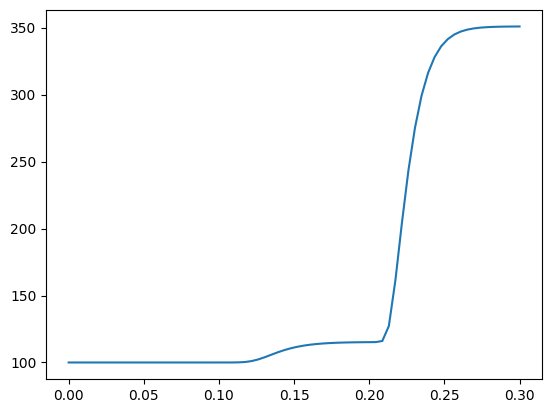

In [95]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, Tf)

In [144]:
import numpy as np

# -----------------------
# Constants (cgs)
# -----------------------
AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi

# -----------------------
# Parameters (Dullemond-like toy)
# -----------------------
Teff = 3000.0
Rstar = 2.0 * RSUN
Sigma_1AU = 1e3
pSigma = 1.0

R = 1 * AU
Sigma = Sigma_1AU * (R/AU)**(-pSigma)

Hscale = 0.05 * R

# Grid (cluster toward surface)
nz = 800
zmax = 10 * Hscale
p_stretch = 1.0
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch

# Density (prescribed Gaussian)
rho0 = Sigma / (np.sqrt(2*PI) * Hscale)
rho = rho0 * np.exp(-0.5*(z/Hscale)**2)

# Eddington/Marshak parameter
psi = 1.0/np.sqrt(3.0)

# Opacity power laws (placeholders)
Tref = 100.0
kappaP0 = 1.0
kappaR0 = 1.0
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0*(T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0*(T/Tref)**betaR

# Stellar absorption opacity (placeholder)
kappa_star = kappaP(Teff)

# Grazing incidence + intercepted flux
mu0 = 0.05
alpha_graz = 0.05
F_star_norm = (Rstar/R)**2 * SIGMA_SB * Teff**4
F0 = alpha_graz * F_star_norm

def stellar_heating_q_conservative(rho, z, kappa_star, F0, mu0):
    """
    Conservative heating from beam attenuation:
      F(z)=F0 exp(-tau/mu0)
      q = -dF/dz  (computed by flux differences)
    """
    mu0 = max(mu0, 1e-12)
    rk = rho * kappa_star

    # tau at grid points from top
    tau = np.zeros_like(z)
    for i in range(len(z)-2, -1, -1):
        tau[i] = tau[i+1] + 0.5*(rk[i]+rk[i+1])*(z[i+1]-z[i])

    # flux at interfaces i+1/2
    tau_half = 0.5*(tau[:-1] + tau[1:])
    F_half = F0 * np.exp(-tau_half/mu0)

    # conservative q at cell centers i=1..n-2 (avoid endpoints)
    q = np.zeros_like(z)
    dzc = z[2:] - z[1:-1]
    q[1:-1] = +(F_half[1:] - F_half[:-1]) / np.maximum(dzc, 1e-30)

    # pad boundaries
    q[0]  = q[1]
    q[-1] = q[-2]
    return q

def update_temperature(J, q, rho, Tmin=1.0, Tmax=5000.0, q_floor=1e-60, rho_floor=1e-80):
    """
    Solve (σ/π)T^4 = J + q/(4π ρ κP(T)).
    Bisection per cell (robust).
    """
    Tnew = np.zeros_like(J)
    for i in range(len(J)):
        Ji = max(J[i], 0.0)
        qi = q[i]
        ri = max(rho[i], rho_floor)

        if abs(qi) < q_floor:
            Ti = (PI*Ji/SIGMA_SB)**0.25 if Ji > 0 else Tmin
            Tnew[i] = np.clip(Ti, Tmin, Tmax)
            continue

        def f(Tx):
            return (SIGMA_SB/PI)*Tx**4 - (Ji + qi/(4.0*PI*ri*kappaP(Tx)))

        lo, hi = Tmin, Tmax
        flo, fhi = f(lo), f(hi)

        # expand hi if needed
        if flo*fhi > 0:
            hi_try = hi
            for _ in range(10):
                hi_try *= 2.0
                if hi_try > 1e5:
                    break
                fhi_try = f(hi_try)
                if flo*fhi_try <= 0:
                    hi = hi_try
                    fhi = fhi_try
                    break

        if flo*fhi > 0:
            # fallback: ignore q-term
            Ti = (PI*Ji/SIGMA_SB)**0.25 if Ji > 0 else Tmin
            Tnew[i] = np.clip(Ti, Tmin, Tmax)
        else:
            for _ in range(80):
                mid = 0.5*(lo+hi)
                fmid = f(mid)
                if flo*fmid <= 0:
                    hi = mid
                    fhi = fmid
                else:
                    lo = mid
                    flo = fmid
            Tnew[i] = np.clip(0.5*(lo+hi), Tmin, Tmax)
    return Tnew

def solve_column(max_iter=200, tol=1e-5, relax=0.3, verbose=True):
    # heating fixed by rho for this toy
    q = stellar_heating_q_conservative(rho, z, kappa_star, F0, mu0)

    # initial T
    T = 150.0*np.ones_like(z)

    for it in range(max_iter):
        kapR = kappaR(T)

        # 1) integrate H from midplane using dH/dz = q/(4π), with H(0)=0
        Hmom = np.zeros_like(z)
        for i in range(1, len(z)):
            Hmom[i] = Hmom[i-1] + 0.5*(q[i]+q[i-1])*(z[i]-z[i-1])/(4.0*PI)

        # 2) compute eigenvalue J0 from surface BC H(zmax)=psi*J(zmax)
        integrand = 3.0 * rho * kapR * Hmom
        I = np.trapz(integrand, z)  # ∫ 3 ρ κR H dz
        Hs = Hmom[-1]
        J0 = Hs/psi + I

        # 3) integrate J from midplane: dJ/dz = -3 ρ κR H
        J = np.zeros_like(z)
        J[0] = J0
        for i in range(1, len(z)):
            dJdz_left  = -3.0*rho[i-1]*kapR[i-1]*Hmom[i-1]
            dJdz_right = -3.0*rho[i]*kapR[i]*Hmom[i]
            J[i] = J[i-1] + 0.5*(dJdz_left + dJdz_right)*(z[i]-z[i-1])

        # 4) update T from local radiative equilibrium
        Tnew = update_temperature(J, q, rho)


        # relax + check
        Told = T.copy()
        T = (1.0-relax)*T + relax*Tnew
        rel = np.max(np.abs((T-Told)/np.maximum(Told, 1.0)))

        if verbose and (it % 10 == 0 or rel < tol):
            Fabs = np.trapz(q, z)
            print(f"iter={it:4d} rel={rel:.3e}  Tmid={T[0]:.2f}  Tsfc={T[-1]:.2f}  "
                  f"Fabs={Fabs:.3e}  F0={F0:.3e}  Hs={Hs:.3e}  J0={J0:.3e}")

        if rel < tol:
            break

    return z, rho, q, J, T, Hmom

if __name__ == "__main__":
    z, rho, q, J, T, H = solve_column(verbose=True)
    print("Done. Tmid=", T[0], "Tsfc=", T[-1])


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/3021675774.py:159: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(integrand, z)  # ∫ 3 ρ κR H dz
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/3021675774.py:181: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fabs = np.trapz(q, z)


iter=   0 rel=1.019e+00  Tmid=138.33  Tsfc=138.29  Fabs=1.987e+04  F0=1.987e+04  Hs=1.581e+03  J0=2.750e+03
iter=  10 rel=6.692e-03  Tmid=111.97  Tsfc=111.75  Fabs=1.987e+04  F0=1.987e+04  Hs=1.581e+03  J0=2.761e+03
iter=  20 rel=1.850e-04  Tmid=111.24  Tsfc=111.00  Fabs=1.987e+04  F0=1.987e+04  Hs=1.581e+03  J0=2.761e+03
iter=  29 rel=7.462e-06  Tmid=111.22  Tsfc=110.98  Fabs=1.987e+04  F0=1.987e+04  Hs=1.581e+03  J0=2.761e+03
Done. Tmid= 111.21690339552507 Tsfc= 110.98279290301332


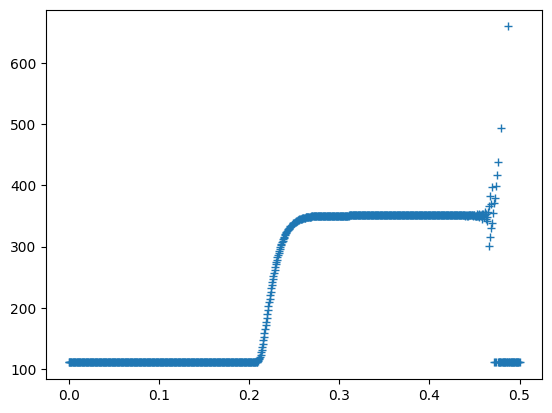

In [145]:
plt.plot(z/AU, T, '+')

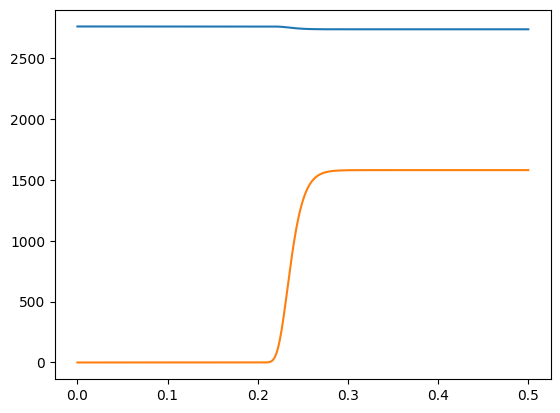

In [146]:
plt.plot(z/AU, J)
plt.plot(z/AU, H)

In [205]:
import numpy as np

# ============================================================
# Constants (cgs)
# ============================================================
AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi

# ============================================================
# User / model parameters (toy Dullemond-like)
# ============================================================
Teff   = 3000.0
Rstar  = 2.0 * RSUN

Sigma_1AU = 1e3
pSigma    = 1.0

R = 1.0 * AU
Sigma = Sigma_1AU * (R / AU) ** (-pSigma)

# Prescribed Gaussian density scale height (NOT iterated)
Hscale = 0.05 * R

# Eddington/Marshak boundary parameter (Two stream approximation)
psi = 1.0 / np.sqrt(3.0)

# Grazing beam
mu0 = 0.05
alpha_graz = 0.05  # intercepted fraction (toy)

# Grid
nz = 800
zmax = 12.0 * Hscale
p_stretch = 1.0  # cluster points toward surface
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch

# Density profile (upper half)
rho0 = Sigma / (np.sqrt(2*PI) * Hscale)
rho = rho0 * np.exp(-0.5 * (z/Hscale)**2)

# ============================================================
# Opacity model (placeholder power laws)
# ============================================================
Tref = 100.0
kappaP0 = 1.0
kappaR0 = 1.0
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0 * (T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0 * (T/Tref)**betaR

# Stellar absorption opacity (placeholder)
kappa_star = kappaP(Teff)

# Stellar flux at radius R (normal incidence), then intercepted
F_star_norm = (Rstar/R)**2 * SIGMA_SB * Teff**4
F0 = alpha_graz * F_star_norm  # intercepted flux per disk face (toy)

# ============================================================
# Conservative heating q(z) from attenuated downward stellar flux
#
# Coordinate: z increases upward from midplane.
# Define F_down(z) = magnitude of downward stellar flux (>0).
# Then the *vector* flux is Fz = -F_down.
# Absorbed power per volume: q = -dFz/dz = + dF_down/dz  (>=0).
# ============================================================
def stellar_heating_q_conservative(rho, z, kappa_star, F0, mu0):
    mu0 = max(mu0, 1e-12)

    rk = rho * kappa_star

    # tau(z) from top: tau(z) = ∫_z^{zmax} rho*kappa dz
    tau = np.zeros_like(z)
    for i in range(len(z)-2, -1, -1):
        tau[i] = tau[i+1] + 0.5*(rk[i]+rk[i+1])*(z[i+1]-z[i])

    # downward flux magnitude at interfaces
    tau_half = 0.5*(tau[:-1] + tau[1:])
    F_half = F0 * np.exp(-tau_half/mu0)

    # conservative q at cell centers i=1..n-2:
    # q = + dF_down/dz  (note the + sign!)
    q = np.zeros_like(z)
    dzc = z[2:] - z[1:-1]
    q[1:-1] = (F_half[1:] - F_half[:-1]) / np.maximum(dzc, 1e-30)
    q[1:-1] = (F_half[1:] - F_half[:-1]) / dzc
    
    # pad endpoints
    q[0]  = q[1]
    q[-1] = q[-2]

    # clip tiny negative roundoff
    q = np.maximum(q, 0.0)
    return q, tau

def stellar_heating_q(rho, z, kappa_star, F_star, mu0):
    """
    Simple 1D attenuated grazing beam from +z:
        tau(z) = ∫_z^∞ rho kappa_star dz'
        q(z) = rho kappa_star F_star * exp(-tau/mu0)
    (Units: erg cm^-3 s^-1)

    This is a simplified 'direct irradiation' heating profile.
    """
    # optical depth from top downward (compute on upper-half grid)
    # tau_top[i] = ∫_{z[i]}^{zmax} rho*kappa dz
    integrand = rho * kappa_star
    tau_top = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(len(z)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(z[i+1]-z[i])

    q = rho * kappa_star * F_star * np.exp(-tau_top/np.maximum(mu0, 1e-6))
    return q, tau_top


# ============================================================
# Main solver: eigenvalue integration for J,H + explicit T update
# ============================================================
def solve_column(
    max_iter=300,
    tol=1e-6,
    omega_T=0.2,      # under-relaxation for T (smaller for inner radii)
    Tmin=1.0,
    Tmax=8000.0,
    rho_floor=1e-80,
    kap_floor=1e-20,
    verbose=True
):
    # heating (fixed because rho fixed in this toy)
    # Stellar flux at radius R (normal incidence)
    F_star = (Rstar/R)**2 * SIGMA_SB * Teff**4  # erg/cm^2/s
    q, tau = stellar_heating_q(rho, z, kappa_star, F_star, mu0)

    # initial guess
    T = 150.0 * np.ones_like(z)

    for it in range(max_iter):
        Told = T.copy()

        # Opacities from last iterate
        kapR = np.maximum(kappaR(T), kap_floor)
        kapP_old = np.maximum(kappaP(T), kap_floor)  # lagged kappa_P

        # ------------------------------------------------------------
        # (1) Integrate H from midplane using dH/dz = q/(4π), H(0)=0
        # ------------------------------------------------------------
        Hmom = np.zeros_like(z)
        for i in range(1, len(z)):
            Hmom[i] = Hmom[i-1] + 0.5*(q[i]+q[i-1])*(z[i]-z[i-1])/(4.0*PI)

        # ------------------------------------------------------------
        # (2) Compute eigenvalue J0 from surface BC: H(zmax) = psi J(zmax)
        # dJ/dz = -3 rho kappa_R H  ->  J(zmax) = J0 - ∫ 3 rho kappa_R H dz
        # => J0 = Hs/psi + ∫ 3 rho kappa_R H dz
        # ------------------------------------------------------------
        integrand = 3.0 * rho * kapR * Hmom
        I = np.trapz(integrand, z)
        Hs = Hmom[-1]
        J0 = Hs/psi + I
        J0 = max(J0, 0.0)

        # ------------------------------------------------------------
        # (3) Integrate J upward: dJ/dz = -3 rho kappa_R H, with J(0)=J0
        # ------------------------------------------------------------
        J = np.zeros_like(z)
        J[0] = J0
        for i in range(1, len(z)):
            dJdz_L = -3.0 * rho[i-1] * kapR[i-1] * Hmom[i-1]
            dJdz_R = -3.0 * rho[i]   * kapR[i]   * Hmom[i]
            J[i] = J[i-1] + 0.5*(dJdz_L + dJdz_R)*(z[i]-z[i-1])

        # clip any tiny negative numerical noise
        J = np.maximum(J, 0.0)

        # ------------------------------------------------------------
        # (4) Explicit T update (lagged kappa_P):
        #     (σ/π) T^4 = J + q/(4π ρ κP(T_old))
        # ------------------------------------------------------------
        rho_eff = np.maximum(rho, rho_floor)
        source = J + q / (4.0*PI*rho_eff*kapP_old)
        source = np.maximum(source, 0.0)

        T_explicit = ((PI / SIGMA_SB) * source) ** 0.25
        T_explicit = np.clip(T_explicit, Tmin, Tmax)

        # under-relaxation
        T = (1.0 - omega_T) * T + omega_T * T_explicit
        T = np.clip(T, Tmin, Tmax)

        # ------------------------------------------------------------
        # convergence + diagnostics
        # ------------------------------------------------------------
        rel = np.max(np.abs((T - Told) / np.maximum(Told, 1.0)))

        if verbose and (it % 10 == 0 or rel < tol):
            Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough
            print(
                f"iter={it:4d} rel={rel:.3e}  "
                f"Tmid={T[0]:.2f}  Tsfc={T[-1]:.2f}  "
                f"minJ={J.min():.3e} maxJ={J.max():.3e}  "
                f"Fabs={Fabs:.3e} F0={F0:.3e}  "
                f"Hs={Hs:.3e} J0={J0:.3e}  "
                f"minq={q.min():.3e} maxq={q.max():.3e}"
            )

        if rel < tol:
            break

    # mirror to full z (optional)
    #z_full = np.concatenate((-z[:0:-1], z))
    #T_full = np.concatenate((T[:0:-1], T))
    #J_full = np.concatenate((J[:0:-1], J))
    #rho_full = np.concatenate((rho[:0:-1], rho))
    #q_full = np.concatenate((q[:0:-1], q))
    #H_full = np.concatenate((-Hmom[:0:-1], Hmom))  # antisymmetric

    return z, rho, q, Hmom, J, T,

# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    zf, rhof, qf, Hf, Jf, Tf, = solve_column(
        max_iter=400,
        tol=1e-6,
        omega_T=0.15,   # try 0.1–0.3; smaller is safer for inner radii
        verbose=True
    )
    mid = len(zf)//2
    print("\nDone.")
    print(f"Midplane: T={Tf[mid]:.2f} K, J={Jf[mid]:.3e}")


iter=   0 rel=2.831e-01  Tmid=144.16  Tsfc=192.47  minJ=2.737e+03 maxJ=2.749e+03  Fabs=1.986e+04 F0=1.987e+04  Hs=1.580e+03 J0=2.749e+03  minq=0.000e+00 maxq=4.739e-08
iter=  10 rel=1.311e-02  Tmid=117.67  Tsfc=332.27  minJ=2.737e+03 maxJ=2.759e+03  Fabs=1.986e+04 F0=1.987e+04  Hs=1.580e+03 J0=2.759e+03  minq=0.000e+00 maxq=4.739e-08
iter=  20 rel=1.990e-03  Tmid=112.47  Tsfc=348.44  minJ=2.737e+03 maxJ=2.760e+03  Fabs=1.986e+04 F0=1.987e+04  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  30 rel=3.953e-04  Tmid=111.45  Tsfc=350.46  minJ=2.737e+03 maxJ=2.760e+03  Fabs=1.986e+04 F0=1.987e+04  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  40 rel=7.789e-05  Tmid=111.25  Tsfc=350.71  minJ=2.737e+03 maxJ=2.760e+03  Fabs=1.986e+04 F0=1.987e+04  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  50 rel=1.533e-05  Tmid=111.21  Tsfc=350.74  minJ=2.737e+03 maxJ=2.760e+03  Fabs=1.986e+04 F0=1.987e+04  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.

/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/4192399485.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(integrand, z)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_18195/4192399485.py:206: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough


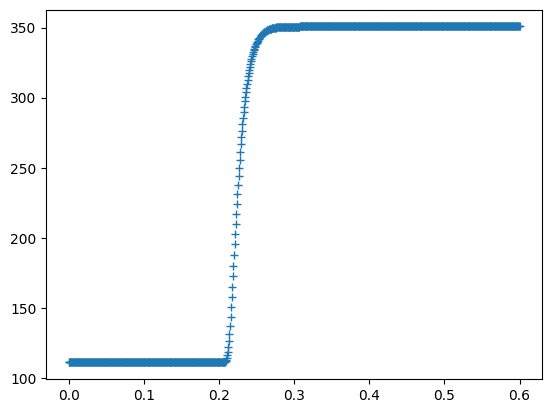

In [206]:
plt.plot(zf/AU, Tf, '+')

[]

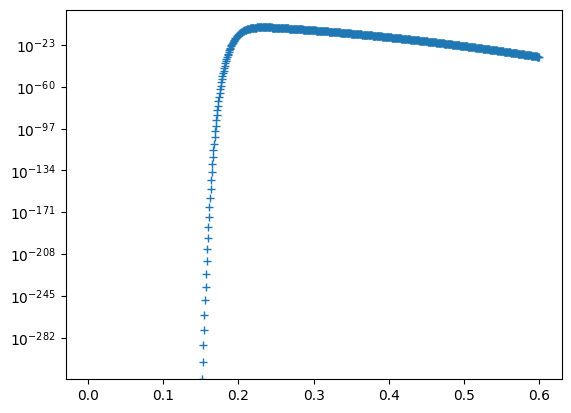

In [207]:
plt.plot(zf/AU, qf, '+')
plt.plot()
plt.semilogy()

(10000.0, 100000000.0)

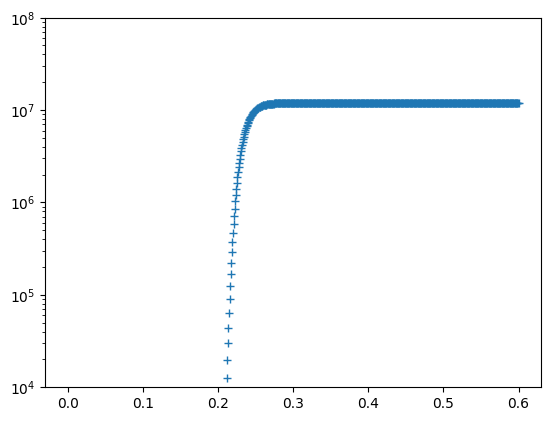

In [208]:
plt.plot(zf/AU, qf / rhof, '+')
plt.semilogy()
plt.ylim(1e4, 1e8)

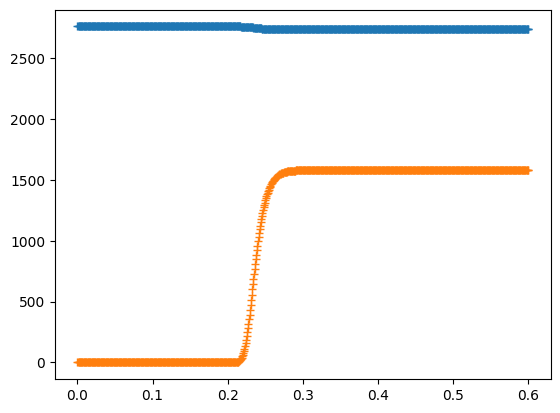

In [210]:
plt.plot(zf/AU, Jf, '+')
plt.plot(zf/AU, Hf, '+')